In [1]:
# Core Data & ML
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Load the Iris Benchmark Dataset
iris = load_iris()

# Convert to DataFrame for easy exploration
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print('=' * 50)
print('         IRIS DATASET — ARCHITECTURE BRIEF')
print('=' * 50)
print(f'Total Samples  : {len(df)}')
print(f'Features       : {len(iris.feature_names)}')
print(f'Classes        : {list(iris.target_names)}')
print(f'Balanced?      : {df["species"].value_counts().to_dict()}')
print()
print('--- First 5 rows ---')
df.head()

         IRIS DATASET — ARCHITECTURE BRIEF
Total Samples  : 150
Features       : 4
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Balanced?      : {'setosa': 50, 'versicolor': 50, 'virginica': 50}

--- First 5 rows ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Statistical Summary
print('--- Dataset Statistics ---')
df.describe().round(2)

--- Dataset Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [4]:
# Separate Features (X) and Target (y)
X = iris.data    # shape: (150, 4)
y = iris.target  # 0=setosa, 1=versicolor, 2=virginica

# GATEKEEPER: StandardScaler — Mean=0, Variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Scaling complete!')
print(f'Before scaling — Mean: {X[:, 0].mean():.2f}, Std: {X[:, 0].std():.2f}')
print(f'After  scaling — Mean: {X_scaled[:, 0].mean():.2f}, Std: {X_scaled[:, 0].std():.2f}')

✅ Scaling complete!
Before scaling — Mean: 5.84, Std: 0.83
After  scaling — Mean: -0.00, Std: 1.00


In [5]:
# Structural Integrity: The Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # reproducibility
    shuffle=True        # remove order bias
)

print('✅ Train-Test Split complete!')
print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/150*100:.0f}%)')
print(f'Testing set    : {X_test.shape[0]} samples  ({X_test.shape[0]/150*100:.0f}%)')

✅ Train-Test Split complete!
Training set   : 120 samples (80%)
Testing set    : 30 samples  (20%)


---
## 🤖 Step 5 — PROCESS: KNN Algorithm (K=5)
> **Proximity Principle:** Similar things exist in close proximity. K=5 → majority vote among 5 nearest neighbors.

In [6]:
# INSTANTIATE — Build the frame
model = KNeighborsClassifier(n_neighbors=5)

# FIT — Memorize the map (training)
model.fit(X_train, y_train)

# PREDICT — Apply logic to test data
y_pred = model.predict(X_test)

print('✅ Model trained and predictions made!')
print(f'Predictions : {y_pred}')
print(f'Actual      : {y_test}')

✅ Model trained and predictions made!
Predictions : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual      : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [7]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score (weighted — handles multiclass)
f1 = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print('         OUTPUT VALIDATION REPORT')
print('=' * 45)
print(f'Accuracy Score  : {accuracy * 100:.2f}%')
print(f'F1 Score        : {f1:.4f}')
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

         OUTPUT VALIDATION REPORT
Accuracy Score  : 100.00%
F1 Score        : 1.0000

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---
## 🗺️ Step 7 — OUTPUT: Confusion Matrix (Heatmap)

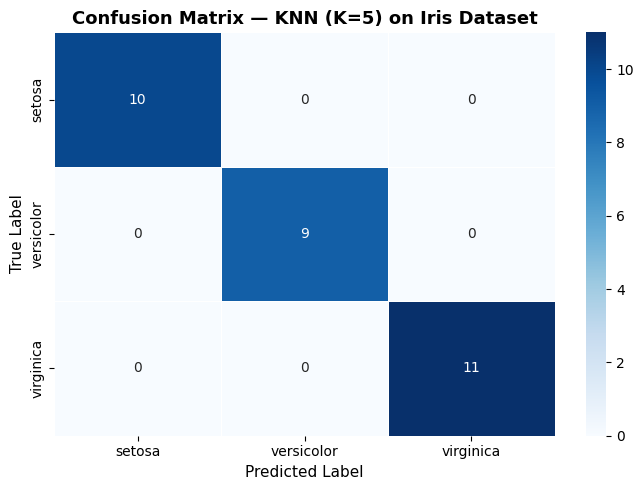

Diagonal = Correct predictions (TP). Off-diagonal = Errors (FP / FN).


In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — KNN (K=5) on Iris Dataset', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()
print('Diagonal = Correct predictions (TP). Off-diagonal = Errors (FP / FN).')

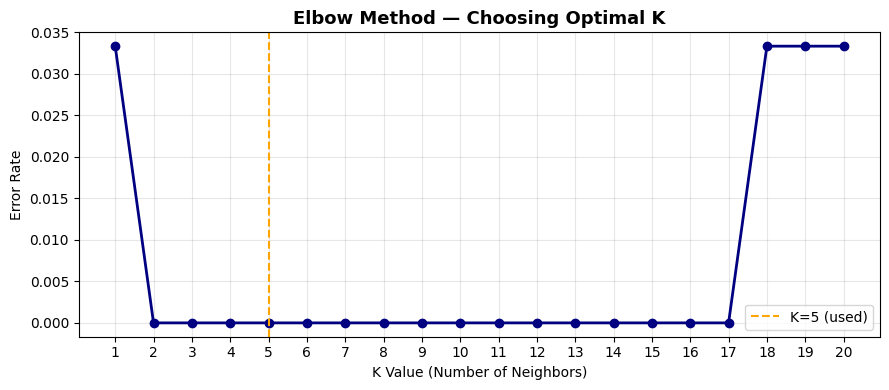

✅ Optimal K = 2 (lowest error rate = 0.0000)


In [9]:
# Test K values from 1 to 20
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

# Plot
plt.figure(figsize=(9, 4))
plt.plot(k_range, error_rates, marker='o', color='navy', linewidth=2, markersize=6)
plt.axvline(x=5, color='orange', linestyle='--', label='K=5 (used)')
plt.title('Elbow Method — Choosing Optimal K', fontsize=13, fontweight='bold')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[error_rates.index(min(error_rates))]
print(f'✅ Optimal K = {best_k} (lowest error rate = {min(error_rates):.4f})')

---
## ✅ Project 2 — Summary

| Component | Detail |
|---|---|
| **Dataset** | Iris — 150 samples, 4 features, 3 classes |
| **Scaling** | StandardScaler (Mean=0, Variance=1) |
| **Split** | 80% Train / 20% Test (shuffled) |
| **Algorithm** | K-Nearest Neighbors (K=5) |
| **Evaluation** | Accuracy + Confusion Matrix + F1 Score |

> **Key Insight:** Accuracy alone can be misleading (Accuracy Mirage). F1 Score balances Precision and Recall — use it for reliable evaluation.